In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
def memory_sim(tau, p = 0.1, dt = 1e-9, n_steps = 1000):
    
    t = np.arange(0, n_steps)*dt
    m = np.zeros(n_steps)
    for i in range(1, n_steps):
        m[i] = m[i-1] * np.exp(-dt / tau)
        if np.random.rand() < p:
            m[i] += 1

    return t, m 

def dynamic_resistance(m, m0, R_min = 10, R_max = 50):
    return R_min + (R_max - R_min) * np.exp(-m / m0)

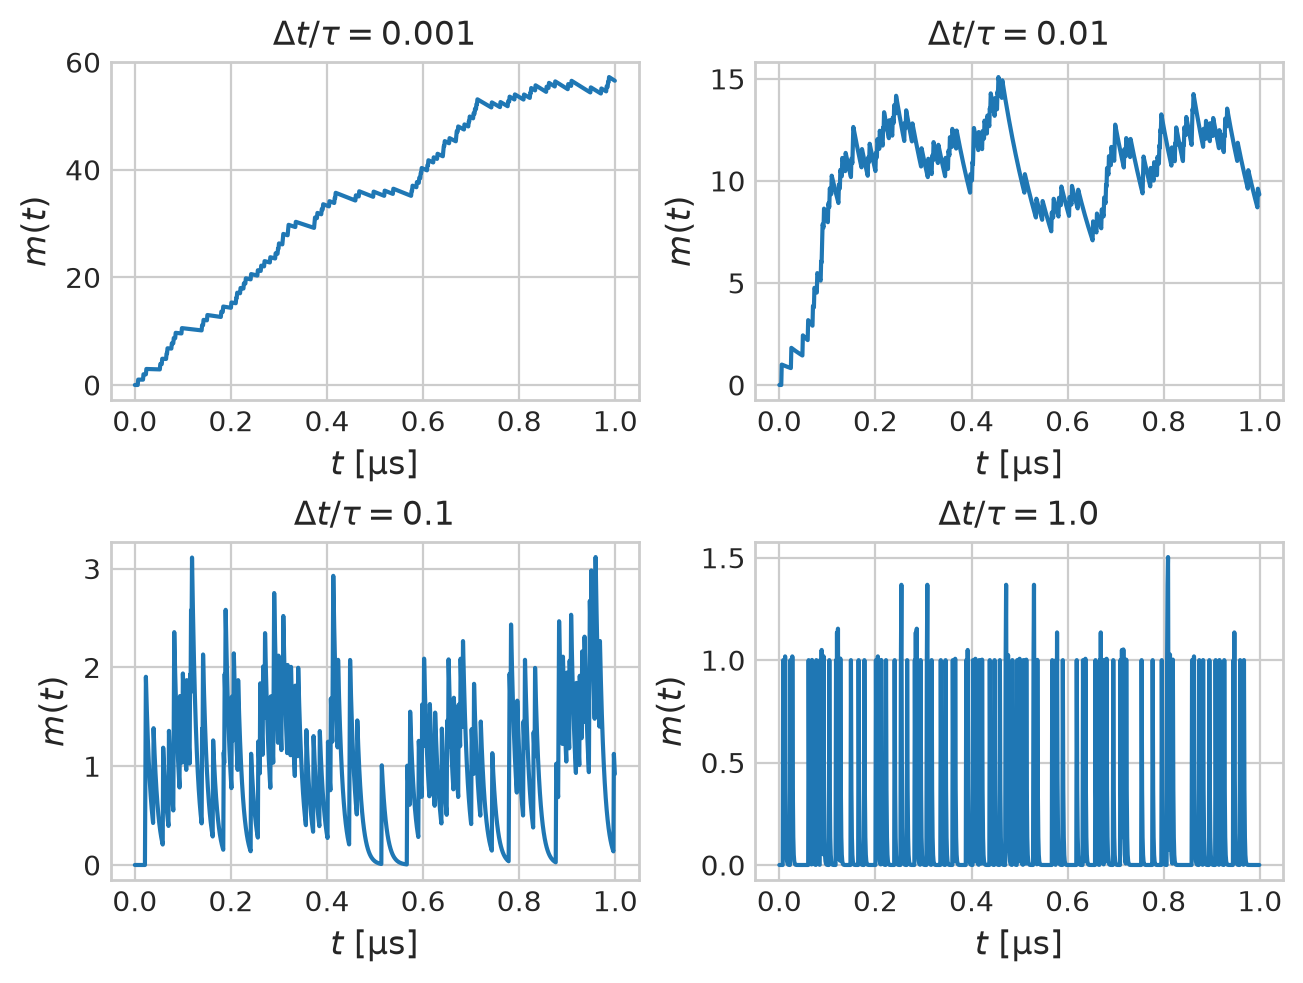

In [27]:
dt = 1e-9
taus = [1e-6,1e-7,1e-8,1e-9]
fig = plt.figure(dpi=200, layout='constrained')

for i, tau in enumerate(taus):
    t, m = memory_sim(tau, dt=dt)
    ax  = fig.add_subplot(2,2,i+1)
    _   = ax.plot(t*1e6, m)
    _   = ax.set_xlabel("$t$ $\\mathrm{{[\\mu s]}}$", size='large')
    _   = ax.set_ylabel("$m(t)$", size='large')
    _   = ax.set_title(f"$\\Delta t / \\tau = {dt/tau}$")

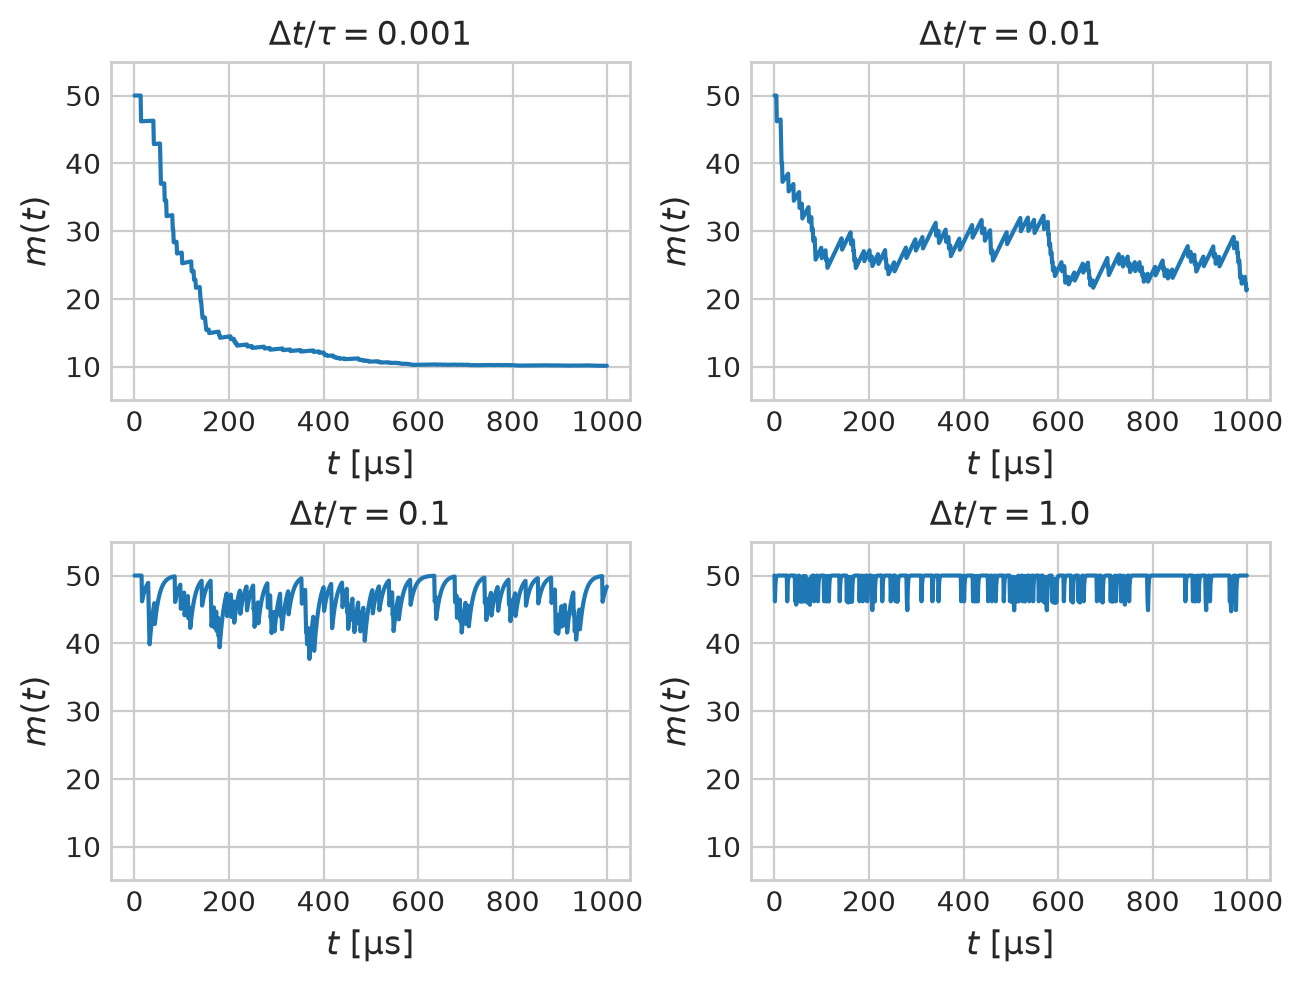

In [57]:
dt = 1e-9
taus = [1e-6,1e-7,1e-8,1e-9]
fig = plt.figure(dpi=200, layout='constrained')

for i, tau in enumerate(taus):
    t, m = memory_sim(tau, dt=dt)
    r   = dynamic_resistance(m, 10)
    ax  = fig.add_subplot(2,2,i+1)
    _   = ax.plot(r)
    _   = ax.set_xlabel("$t$ $\\mathrm{{[\\mu s]}}$", size='large')
    _   = ax.set_ylabel("$m(t)$", size='large')
    _   = ax.set_title(f"$\\Delta t / \\tau = {dt/tau}$")
    _   = ax.set_ylim(5,55)

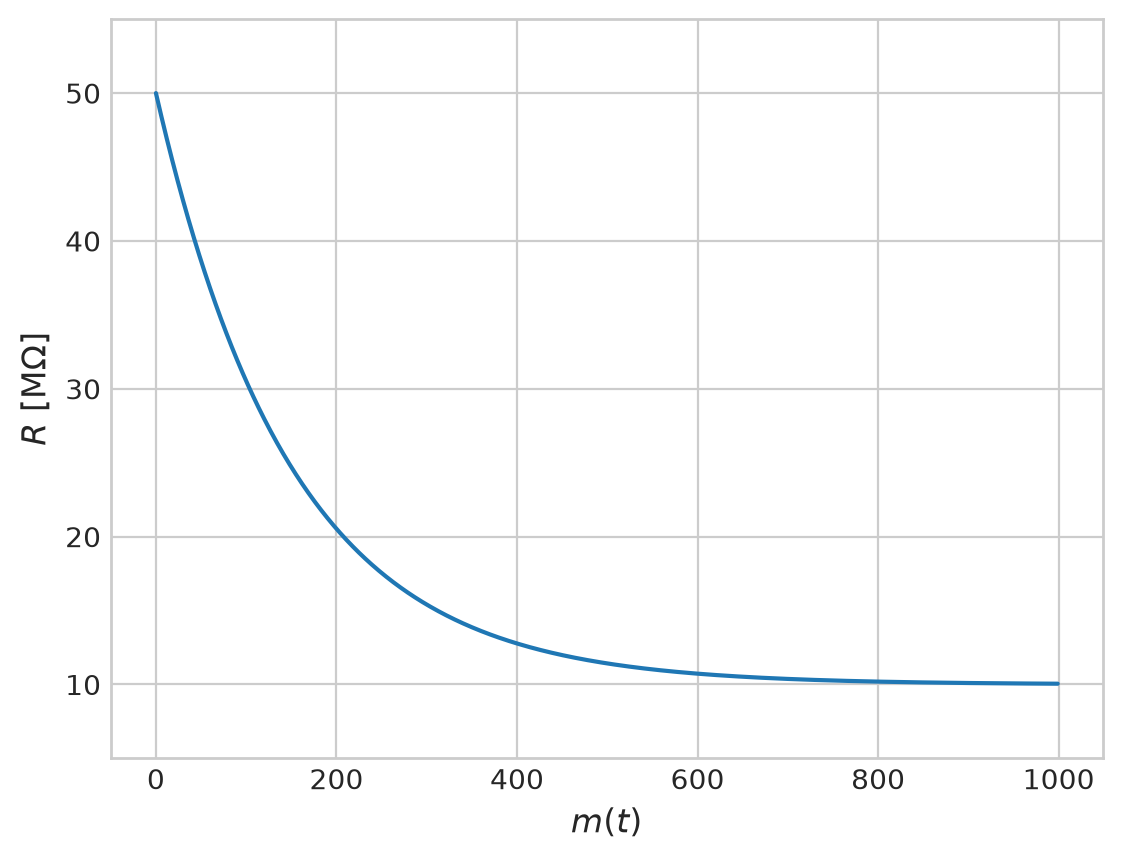

In [48]:
fig = plt.figure(dpi=200)

m   = np.linspace(0,10,1000)
r   = dynamic_resistance(m, 1.5)
ax  = fig.add_subplot()
_   = ax.plot(r)
_   = ax.set_ylabel("$R$ $\\mathrm{{[M\\Omega]}}$", size='large')
_   = ax.set_xlabel("$m(t)$", size='large')
_   = ax.set_ylim(5,55)